In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split  
import pandas as pd
#分块处理大文件
# chunk_iter = pd.read_csv("data/train_data.csv", chunksize=10000)
# chunks = [chunk for chunk in chunk_iter]
# train_data = pd.concat(chunks)
train_data = pd.read_csv("train/train_statement_feature.csv")
test_data = pd.read_csv("testaa/testaa_statement_feature.csv")

train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21728 entries, 0 to 21727
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      21728 non-null  int64  
 1   total_income            21728 non-null  float64
 2   total_expense           21728 non-null  float64
 3   net_income              21728 non-null  float64
 4   income_count            21728 non-null  int64  
 5   expense_count           21728 non-null  int64  
 6   total_tx_count          21728 non-null  int64  
 7   active_days             21728 non-null  int64  
 8   tx_frequency            21728 non-null  float64
 9   last_tx_days_ago        21728 non-null  int64  
 10  income_expense_ratio    21728 non-null  float64
 11  avg_income              21728 non-null  float64
 12  income_std              21728 non-null  float64
 13  expense_std             21728 non-null  float64
 14  big_income_count        21728 non-null

In [28]:
train_data.head()

,id,total_income,total_expense,net_income,income_count,expense_count,total_tx_count,active_days,tx_frequency,last_tx_days_ago,...,big_income_ratio,min_balance,final_balance,negative_balance_count,negative_balance_ratio,salary_count,salary_avg,salary_std,salary_ratio,label
0,0,12079.50,59707.50,-47628.00,42,6,48,164,0.292683,5996,...,0.000000,-48391.79,-47628.00,48.0,1.000000,0.0,0.0,0.0,0.0,0
1,12893,14368.58,14022.76,345.82,54,6,60,165,0.363636,6281,...,0.018519,-3227.26,345.82,42.0,0.700000,0.0,0.0,0.0,0.0,0
2,6446,31500.04,15115.50,16384.54,69,6,75,171,0.438596,6446,...,0.072464,-3633.28,16384.54,21.0,0.280000,0.0,0.0,0.0,0.0,0
3,2,15883.72,6522.38,9361.34,44,4,48,181,0.265193,4309,...,0.045455,-951.78,9361.34,4.0,0.083333,0.0,0.0,0.0,0.0,0
4,4,30823.10,20339.90,10483.20,87,6,93,170,0.547059,5995,...,0.057471,-4481.30,10483.20,39.0,0.419355,0.0,0.0,0.0,0.0,1


In [29]:
###   特征工程
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1. 删除id列（正确用法）
train_data.drop('id', axis=1, inplace=True)  # 不赋值，直接修改原对象
cat_features = [
    'income_count', 'expense_count', 'big_income_count',
     'negative_balance_count'
]
train_data.drop('salary_count',axis = 1, inplace=True)
train_data.drop('salary_avg',axis = 1, inplace=True)
train_data.drop('salary_std',axis = 1, inplace=True)
train_data.drop('salary_ratio',axis = 1, inplace=True)
test_data.drop('salary_count',axis = 1, inplace=True)
test_data.drop('salary_avg',axis = 1, inplace=True)
test_data.drop('salary_std',axis = 1, inplace=True)
test_data.drop('salary_ratio',axis = 1, inplace=True)
for fea in cat_features:
    train_data[fea] = train_data[fea].astype('int64')
    test_data[fea] = test_data[fea].astype('int64')    

In [30]:
from sklearn.model_selection import train_test_split
feature_list = [col for col in train_data.columns if col != "label"]
X_train, X_validation, y_train, y_validation = train_test_split(train_data.loc[:, feature_list], train_data.loc[:, 'label'], test_size=0.2 , random_state=2000)

In [31]:
# 3. 模型建立与训练
# 确保 Notebook 内联显示图形
%matplotlib inline 
from catboost import CatBoostClassifier

model = CatBoostClassifier(iterations=2000,
                           task_type='CPU',
                           cat_features=cat_features,
                           eval_metric='AUC',
                           logging_level='Verbose',
                           learning_rate=0.03,
                           depth=6, 
                           l2_leaf_reg=5,
                           loss_function='Logloss',
                            early_stopping_rounds=300,
                           scale_pos_weight=(len(y_train[y_train==0])/len(y_train[y_train == 1])))
'''
model = CatBoostClassifier(iterations=5000,
                           cat_features=feature_list,
                           eval_metric='AUC',
                           logging_level='Verbose',
                           learning_rate=0.01,
                           depth=6, l2_leaf_reg=5,
                           loss_function='CrossEntropy')
                           '''
model.fit(X_train.loc[:, feature_list], y_train, 
          eval_set=(X_validation.loc[:, feature_list], y_validation), plot=True)

plt.show()

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	test: 0.5987860	best: 0.5987860 (0)	total: 44.2ms	remaining: 1m 28s
1:	test: 0.6019521	best: 0.6019521 (1)	total: 75.5ms	remaining: 1m 15s
2:	test: 0.6143819	best: 0.6143819 (2)	total: 98.3ms	remaining: 1m 5s
3:	test: 0.6161984	best: 0.6161984 (3)	total: 114ms	remaining: 56.7s
4:	test: 0.6204073	best: 0.6204073 (4)	total: 135ms	remaining: 53.7s
5:	test: 0.6210187	best: 0.6210187 (5)	total: 155ms	remaining: 51.4s
6:	test: 0.6235974	best: 0.6235974 (6)	total: 188ms	remaining: 53.6s
7:	test: 0.6217617	best: 0.6235974 (6)	total: 215ms	remaining: 53.6s
8:	test: 0.6224621	best: 0.6235974 (6)	total: 233ms	remaining: 51.6s
9:	test: 0.6223375	best: 0.6235974 (6)	total: 252ms	remaining: 50.2s
10:	test: 0.6229739	best: 0.6235974 (6)	total: 277ms	remaining: 50.1s
11:	test: 0.6224435	best: 0.6235974 (6)	total: 303ms	remaining: 50.1s
12:	test: 0.6222968	best: 0.6235974 (6)	total: 326ms	remaining: 49.9s
13:	test: 0.6221615	best: 0.6235974 (6)	total: 348ms	remaining: 49.4s
14:	test: 0.6224369	best:

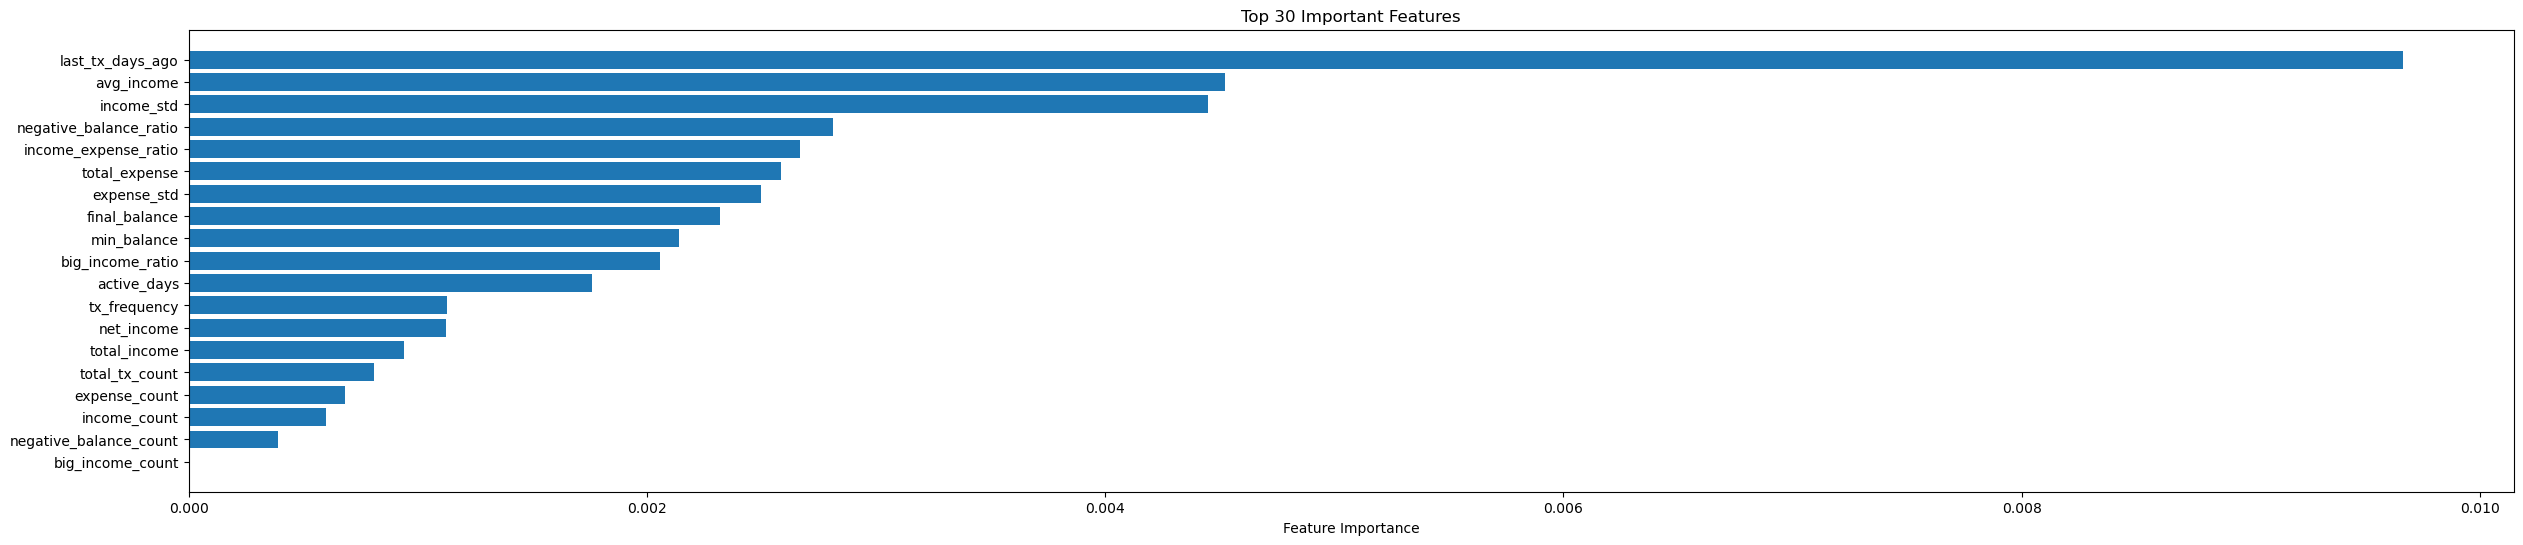

Feature 0: 0.0009383272131417986
Feature 1: 0.002584609146501382
Feature 2: 0.0011229784396031839
Feature 3: 0.0005989487123579385
Feature 4: 0.0006808037366934732
Feature 5: 0.0008081947870021515
Feature 6: 0.0017617540599805803
Feature 7: 0.0011280972279751333
Feature 8: 0.009664019636749788
Feature 9: 0.0026699094720845085
Feature 10: 0.004521968168009316
Feature 11: 0.004449019226921425
Feature 12: 0.002498740849139147
Feature 13: 7.514949842672258e-06
Feature 14: 0.0020572672754470833
Feature 15: 0.0021410158778650823
Feature 16: 0.0023178520458048135
Feature 17: 0.0003900742856796091
Feature 18: 0.0028106704071892974


In [32]:
import catboost
# 假设 df 是你的 Pandas DataFrame
train_data = catboost.Pool(data=X_train, label=y_train,cat_features=cat_features)
# 获取特征重要性评估
feature_importance = model.get_feature_importance(data=train_data, type='LossFunctionChange')
# 获取特征名称
feature_names = train_data.get_feature_names()
# 将特征重要性和特征名称结合起来，创建一个字典
feature_importance_dict = dict(zip(feature_names, feature_importance))

# 将特征重要性排序
sorted_feature_importance = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)

# 提取排序后的特征名称和重要性
sorted_feature_names, sorted_feature_importance = zip(*sorted_feature_importance)

plt.figure(figsize=(30, 6))
plt.barh(sorted_feature_names[:30], sorted_feature_importance[:30])
plt.xlabel('Feature Importance')
plt.title('Top 30 Important Features')
plt.gca().invert_yaxis()  # 反转y轴以显示重要性高的特征在顶部
plt.show()
# 打印特征重要性得分
for i, score in enumerate(feature_importance):
    print(f'Feature {i}: {score}')